# Importamos el dataset


In [2]:
import os
import zipfile
import pandas as pd
import glob
from google.colab import drive

# --- PASO 1: MONTAMOS DRIVE Y DESCOMPRIMIR ---
# Montar Drive
drive.mount("/content/drive")

# Ruta del ZIP
zip_path = "/content/drive/MyDrive/TRABAJO FINAL DE VISION ARTIFICIAL/BodyM_dataset.zip"
extract_path = "/content/BodyM_dataset_rescate"

# Descomprimir
print(f" Descomprimiendo {zip_path}...")
try:
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_path)
    print(" Descompresión completada.")
except FileNotFoundError:
    print(f" ERROR: No encuentro el ZIP en: {zip_path}")
    print(" Por favor, verifica en la carpeta de la izquierda en qué ruta exacta está tu 'BodyM_dataset.zip' y corrige la variable 'zip_path' arriba.")
    raise # Detenemos si no hay zip

# --- PASO 2: BUSCAMOS EL CSV DE MEDIDAS ---
print("\n Buscando 'measurements.csv'...")

csv_encontrado = None
mapa_encontrado = None
raiz_datos = None

# Buscamos recursivamente en la carpeta donde descomprimimos
for root, dirs, files in os.walk(extract_path):
    if "measurements.csv" in files:
        csv_encontrado = os.path.join(root, "measurements.csv")
        raiz_datos = root # Guardamos esta carpeta como la "buena"
        print(f"   -> ¡MEDIDAS ENCONTRADAS!: {csv_encontrado}")

    if "subject_to_photo_map.csv" in files:
        mapa_encontrado = os.path.join(root, "subject_to_photo_map.csv")
        print(f"   -> ¡MAPA ENCONTRADO!: {mapa_encontrado}")

if not csv_encontrado:
    print("\n NO SE ENCONTRÓ EL ARCHIVO. Listando qué archivos SÍ existen para diagnosticar:")
    # Listamos los primeros 10 archivos que encontremos para ver qué pasa
    archivos_vistos = []
    for r, d, f in os.walk(extract_path):
        for file in f:
            archivos_vistos.append(os.path.join(r, file))
    print(archivos_vistos[:10])
    raise ValueError("Deteniendo: No está el CSV de medidas.")

# --- PASO 3: CARGAMOS Y UNIMOS LOS DATOS ---
print("\n Uniendo datos...")
df_medidas = pd.read_csv(csv_encontrado)
df_mapa = pd.read_csv(mapa_encontrado)

# Unir tablas
col_comun = list(set(df_medidas.columns) & set(df_mapa.columns))[0]
df_final = pd.merge(df_medidas, df_mapa, on=col_comun)

# Crear rutas de imágenes
# Detectar carpeta de imágenes (mask o mask_left) dentro de la carpeta raíz encontrada
carpeta_img = "mask"
if "mask_left" in os.listdir(raiz_datos):
    carpeta_img = "mask_left"

print(f" Usando carpeta de imágenes: {carpeta_img}")

# Construir ruta absoluta
col_imagen = [c for c in df_final.columns if 'photo' in c or 'image' in c][0]
df_final['path_completo'] = df_final[col_imagen].apply(
    lambda x: os.path.join(raiz_datos, carpeta_img, f"{x}.png" if not str(x).endswith('.png') else x)
)

# --- VERIFICACIÓN FINAL ---
if os.path.exists(df_final['path_completo'].iloc[0]):
    print("\n ¡SISTEMA LISTO! Datos cargados y vinculados.")
    print(" Columnas disponibles para predecir:")
    print(df_final.columns.tolist())
else:
    print(f"\n ALERTA: La ruta generada no existe: {df_final['path_completo'].iloc[0]}")

Mounted at /content/drive
 Descomprimiendo /content/drive/MyDrive/TRABAJO FINAL DE VISION ARTIFICIAL/BodyM_dataset.zip...
 Descompresión completada.

 Buscando 'measurements.csv'...
   -> ¡MEDIDAS ENCONTRADAS!: /content/BodyM_dataset_rescate/train/measurements.csv
   -> ¡MAPA ENCONTRADO!: /content/BodyM_dataset_rescate/train/subject_to_photo_map.csv
   -> ¡MEDIDAS ENCONTRADAS!: /content/BodyM_dataset_rescate/testA/measurements.csv
   -> ¡MAPA ENCONTRADO!: /content/BodyM_dataset_rescate/testA/subject_to_photo_map.csv
   -> ¡MEDIDAS ENCONTRADAS!: /content/BodyM_dataset_rescate/testB/measurements.csv
   -> ¡MAPA ENCONTRADO!: /content/BodyM_dataset_rescate/testB/subject_to_photo_map.csv

 Uniendo datos...
 Usando carpeta de imágenes: mask_left

 ¡SISTEMA LISTO! Datos cargados y vinculados.
 Columnas disponibles para predecir:
['subject_id', 'ankle', 'arm-length', 'bicep', 'calf', 'chest', 'forearm', 'height', 'hip', 'leg-length', 'shoulder-breadth', 'shoulder-to-crotch', 'thigh', 'waist', 

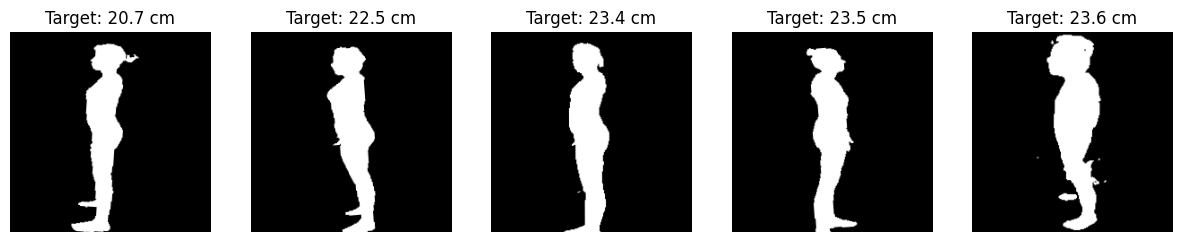

In [13]:
import matplotlib.pyplot as plt

# Obtener un lote de imágenes del generador
x_batch, y_batch = next(train_generator)

# Mostrar las primeras 5 imágenes
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(x_batch[i])
    plt.title(f"Target: {y_batch[i][0]:.1f} cm") # Muestra la primera medida (ej. altura)
    plt.axis('off')
plt.show()

# 1.- Modelo "MobileNetV2"

 Entrenando para predecir: ['ankle', 'arm-length', 'bicep', 'calf', 'chest', 'forearm', 'height', 'hip', 'leg-length', 'shoulder-breadth', 'shoulder-to-crotch', 'thigh', 'waist', 'wrist']
Found 928 validated image filenames.
Found 232 validated image filenames.

 Construyendo MobileNetV2...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,758 (9.25 MB)

 Trainable params: 165,774 (647.55 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


 INICIANDO ENTRENAMIENTO...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 38s 732ms/step - loss: 4498.1914 - mae: 55.2357 - val_loss: 1444.8523 - val_mae: 28.5488
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 534ms/step - loss: 838.6648 - mae: 20.9189 - val_loss: 110.4959 - val_mae: 7.5682
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 536ms/step - loss: 214.5775 - mae: 11.2775 - val_loss: 96.2726 - val_mae: 6.4877
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 566ms/step - loss: 180.4619 - mae: 10.1887 - val_loss: 85.9320 - val_mae: 6.1523
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 542ms/step - loss: 170.2518 - mae: 9.9004 - val_loss: 78.7600 - val_mae: 5.8046
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 21s 556ms/step - loss: 157.5282 - mae: 9.5189 - val_loss: 69.5040 - val_mae: 5.5353
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 573ms/step - loss: 149.8426 - mae: 9.1130 - val_loss: 71.8461 - val_mae: 5.5838
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 544ms/step - loss: 141.0032 - mae: 8.8644 - val_loss: 67.5761 - val_mae: 5.4356
Epoch 9/10
29/2

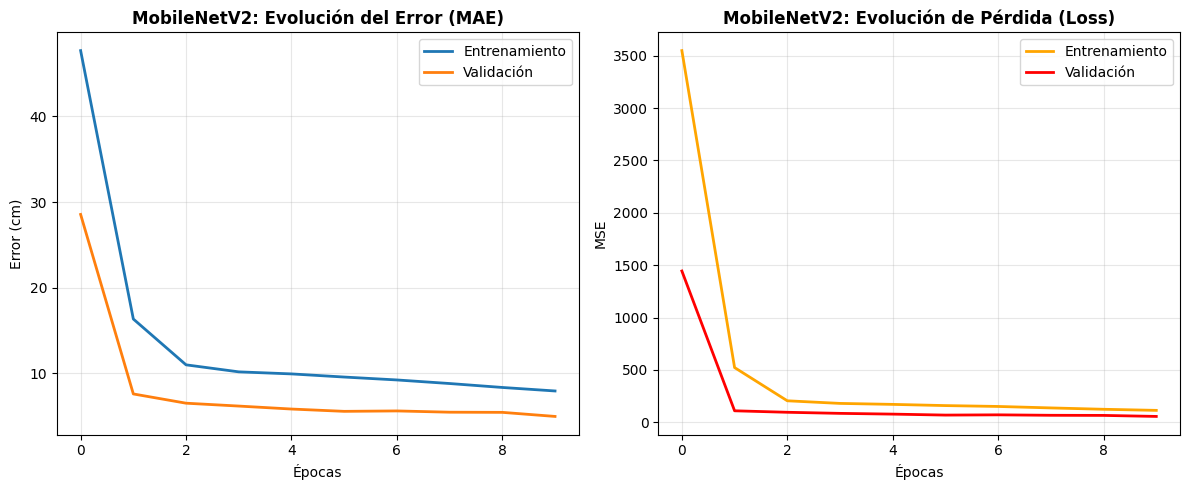


 PRUEBA DE PREDICCIÓN CON UNA IMAGEN REAL (Validación rápida):
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
Medidas Reales (cm): [ 23.42422295  47.1287384   29.74492645  37.69720078  98.71942902
  25.6874218  168.4979248  101.08618927  74.17185974  37.11225128
  64.66703033  52.37804413  87.12102509  16.17978096]
Predicción IA (cm):  [ 23.03226   47.45348   28.636982  35.641277  95.28005   25.394417
 162.22878   98.53105   74.912415  34.270187  60.878582  51.85689
  84.718094  15.808268]
Diferencia:          [0.39196205 0.32474136 1.10794449 2.05592346 3.43937683 0.29300499
 6.26914978 2.55513763 0.74055481 2.8420639  3.78844833 0.5211525
 2.40293121 0.37151337]

 Calculando métricas detalladas para todo el set de validación...
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step

 RESULTADOS FINALES DETALLADOS (MobileNetV2):
                Medida   MAE (cm)   MAPE (%)  Desviación Std (%)
0                ankle   1.613070   6.590588            4.982026
1           arm-length   3.080511   6.383535            

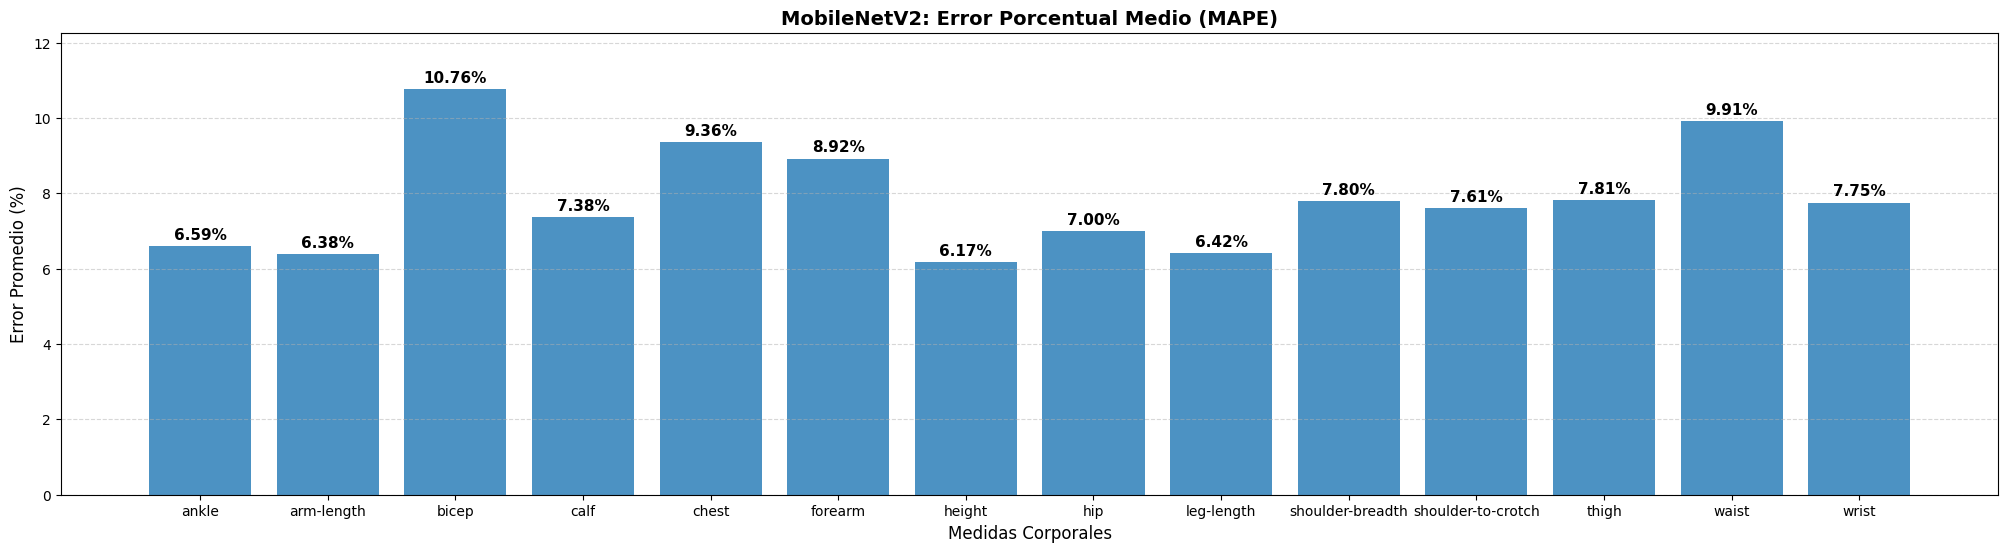

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 1. CONFIGURACION DE OBJETIVOS ---
TARGET_COLS = ['ankle', 'arm-length', 'bicep', 'calf', 'chest', 'forearm', 'height', 'hip', 'leg-length',
               'shoulder-breadth', 'shoulder-to-crotch', 'thigh', 'waist', 'wrist']
print(f" Entrenando para predecir: {TARGET_COLS}")

# Parámetros
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10  # Ajustable según necesidad

# --- 2. PREPARAR GENERADORES ---
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=5,      # Rotación leve (5 grados) para simular cámara no recta
    width_shift_range=0.05, # Mover un poco a los lados
    height_shift_range=0.05, # Mover un poco arriba/abajo
    zoom_range=0.05,        # Zoom muy leve (cuidado con no cortar pies/cabeza)
    horizontal_flip=True,   # Espejo (útil porque el cuerpo humano es simétrico)
    validation_split=0.2
)
# Nota: Para el 'val_generator', usa una instancia separada SIN aumentos, solo rescale.
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Generador de Entrenamiento
train_generator = datagen.flow_from_dataframe(
    dataframe=df_final,
    x_col='path_completo',
    y_col=TARGET_COLS,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='raw',      # 'raw' para regresión
    subset='training',
    shuffle=True
)

# Generador de Validación
val_generator = datagen.flow_from_dataframe(
    dataframe=df_final,
    x_col='path_completo',
    y_col=TARGET_COLS,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    subset='validation',
    shuffle=False
)

# --- 3. CONSTRUIR EL MODELO (MobileNetV2) ---
print("\n Construyendo MobileNetV2...")

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False # Congelar base

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(len(TARGET_COLS), activation='linear')
])

model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model.summary()

# --- 4. ENTRENAMIENTO ---
print("\n INICIANDO ENTRENAMIENTO...")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_steps=val_generator.samples // BATCH_SIZE
)

print("\n Entrenamiento finalizado.")

# --- 5. EVALUACIÓN Y GRÁFICOS  ---

# A) Gráficos de Evolución (Loss y MAE)
plt.figure(figsize=(12, 5))

# Subplot 1: Error Absoluto (MAE)
plt.subplot(1, 2, 1)
plt.plot(history.history['mae'], label='Entrenamiento', linewidth=2)
plt.plot(history.history['val_mae'], label='Validación', linewidth=2)
plt.title('MobileNetV2: Evolución del Error (MAE)', fontsize=12, fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Error (cm)')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Pérdida (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento', color='orange', linewidth=2)
plt.plot(history.history['val_loss'], label='Validación', color='red', linewidth=2)
plt.title('MobileNetV2: Evolución de Pérdida (Loss)', fontsize=12, fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# B) Prueba Rápida (Sanity Check)
print("\n PRUEBA DE PREDICCIÓN CON UNA IMAGEN REAL (Validación rápida):")
val_generator.reset() # Reiniciamos para tomar el primer lote
imgs, labels = next(val_generator)
preds = model.predict(imgs)
print(f"Medidas Reales (cm): {labels[0]}")
print(f"Predicción IA (cm):  {preds[0]}")
print(f"Diferencia:          {np.abs(labels[0] - preds[0])}")

# C) Cálculo Masivo de Métricas (Tabla y Gráfico de Barras)
print("\n Calculando métricas detalladas para todo el set de validación...")
val_generator.reset() # Reiniciamos de nuevo para recorrer todo el set

# Predecir todo el set
preds_mobile = model.predict(val_generator, verbose=1)
y_true = val_generator.labels

# Calcular errores absolutos y porcentuales
errors_abs_mobile = np.abs(y_true - preds_mobile)
errors_pct_mobile = (errors_abs_mobile / y_true) * 100

# DataFrame Resumen
results_df_mobile = pd.DataFrame({
    'Medida': TARGET_COLS,
    'MAE (cm)': np.mean(errors_abs_mobile, axis=0),
    'MAPE (%)': np.mean(errors_pct_mobile, axis=0),
    'Desviación Std (%)': np.std(errors_pct_mobile, axis=0)
})

print("\n RESULTADOS FINALES DETALLADOS (MobileNetV2):")
print(results_df_mobile)

# D) Gráfico de Barras (MAPE)
plt.figure(figsize=(25, 6))
bars = plt.bar(results_df_mobile['Medida'], results_df_mobile['MAPE (%)'], color='#1f77b4', alpha=0.8)

plt.title('MobileNetV2: Error Porcentual Medio (MAPE)', fontsize=14, fontweight='bold')
plt.ylabel('Error Promedio (%)', fontsize=12)
plt.xlabel('Medidas Corporales', fontsize=12)
plt.ylim(0, max(results_df_mobile['MAPE (%)']) + 1.5)
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Etiquetas sobre barras
for bar in bars:

    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.2f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.show()

# 2.- Modelo "EfficientNetB0"

 Entrenando EfficientNetB0 para predecir: ['ankle', 'arm-length', 'bicep', 'calf', 'chest', 'forearm', 'height', 'hip', 'leg-length', 'shoulder-breadth', 'shoulder-to-crotch', 'thigh', 'waist', 'wrist']
Found 928 validated image filenames.
Found 232 validated image filenames.

 Construyendo EfficientNetB0...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,215,345 (16.08 MB)

 Trainable params: 165,774 (647.55 KB)

 Non-trainable params: 4,049,571 (15.45 MB)


 INICIANDO EL COMBATE (Entrenamiento)...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 46s 761ms/step - loss: 5084.5000 - mae: 59.0272 - val_loss: 3626.6714 - val_mae: 47.0780
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 572ms/step - loss: 2829.8506 - mae: 39.1070 - val_loss: 1114.4838 - val_mae: 21.2867
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 543ms/step - loss: 829.5291 - mae: 18.2027 - val_loss: 221.4439 - val_mae: 8.5850
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 20s 535ms/step - loss: 244.1171 - mae: 10.4643 - val_loss: 81.6231 - val_mae: 5.7787
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 17s 574ms/step - loss: 158.4367 - mae: 9.0812 - val_loss: 64.6243 - val_mae: 5.0901
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 535ms/step - loss: 136.8924 - mae: 8.4377 - val_loss: 60.7252 - val_mae: 4.9685
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 16s 539ms/step - loss: 122.4236 - mae: 8.0714 - val_loss: 60.3070 - val_mae: 4.9251
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 15s 535ms/step - loss: 127.8811 - mae: 8.1479 - val_loss: 60.6200 - val_mae: 4.9559
Epoch 9/10


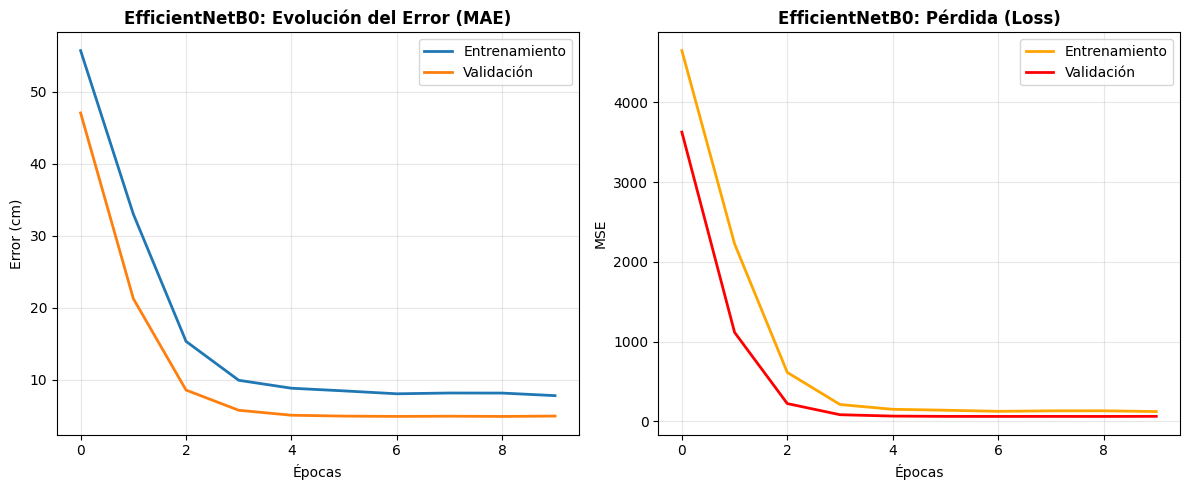


 Calculando métricas detalladas para el informe...
8/8 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step

 RESULTADOS FINALES (EfficientNetB0):
                Medida   MAE (cm)   MAPE (%)  Desviación Std (%)
0                ankle   1.543939   6.401623            4.063985
1           arm-length   2.715956   5.601113            3.510158
2                bicep   3.676851  11.596976            8.830996
3                 calf   2.847891   7.258598            5.501057
4                chest  10.863422  10.185928            7.971020
5              forearm   2.629998   9.792063            5.762938
6               height   8.038932   4.770081            3.188930
7                  hip   8.567263   7.872583            6.602214
8           leg-length   3.968128   5.144301            3.777979
9     shoulder-breadth   2.483389   7.036243            4.537913
10  shoulder-to-crotch   4.318186   6.807562            4.079915
11               thigh   5.054762   8.773000            7.540051
12               waist  11.

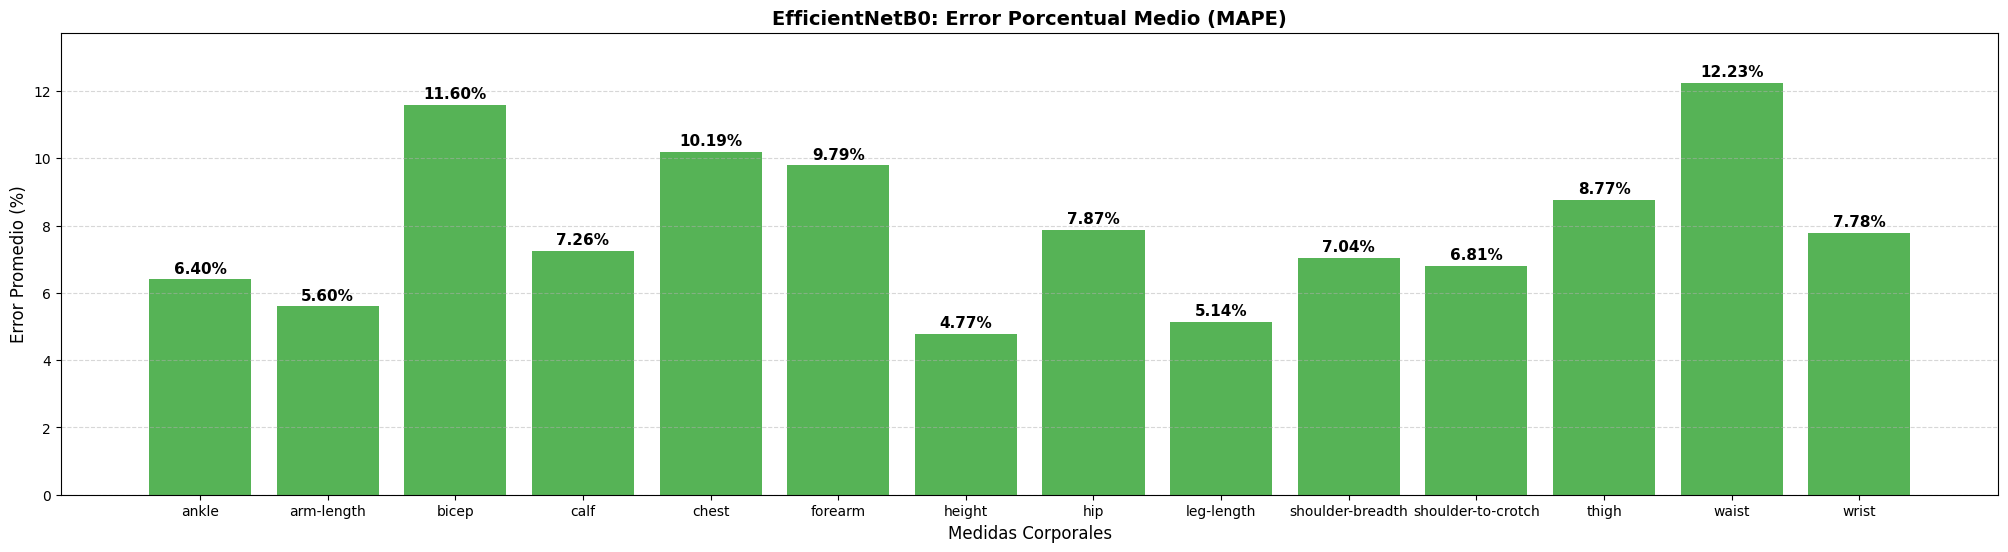


 ¡Modelo guardado en Drive!


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 1. CONFIGURACIÓN ---
# Asegúrate de que df_final ya existe (del paso de carga de datos)
TARGET_COLS = ['ankle', 'arm-length', 'bicep', 'calf', 'chest', 'forearm', 'height', 'hip', 'leg-length',
               'shoulder-breadth', 'shoulder-to-crotch', 'thigh', 'waist', 'wrist']
print(f" Entrenando EfficientNetB0 para predecir: {TARGET_COLS}")

# Parámetros (EfficientNetB0 usa 224x224 por defecto)
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 10

# --- 2. GENERADORES DE DATOS ---
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=5,      # Rotación leve (5 grados) para simular cámara no recta
    width_shift_range=0.05, # Mover un poco a los lados
    height_shift_range=0.05, # Mover un poco arriba/abajo
    zoom_range=0.05,        # Zoom muy leve (cuidado con no cortar pies/cabeza)
    horizontal_flip=True,   # Espejo (útil porque el cuerpo humano es simétrico)
    validation_split=0.2
)
# Nota: Para el 'val_generator', usa una instancia separada SIN aumentos, solo rescale.
val_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

# Entrenamiento
train_generator = datagen.flow_from_dataframe(
    dataframe=df_final,
    x_col='path_completo',
    y_col=TARGET_COLS,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    subset='training',
    shuffle=True
)

# Validación
val_generator = datagen.flow_from_dataframe(
    dataframe=df_final,
    x_col='path_completo',
    y_col=TARGET_COLS,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='raw',
    subset='validation',
    shuffle=False
)

# --- 3. CONSTRUCCION DEL MODELO (EfficientNetB0) ---
print("\n Construyendo EfficientNetB0...")

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False # Congelar para velocidad

model_eff = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(len(TARGET_COLS), activation='linear')
])

model_eff.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

model_eff.summary()

# --- 4. ENTRENAMIENTO ---
print("\n INICIANDO EL COMBATE (Entrenamiento)...")
history_eff = model_eff.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_steps=val_generator.samples // BATCH_SIZE
)

print("\n Entrenamiento finalizado.")

# --- 5. EVALUACIÓN Y GRÁFICOS ---

# A) Evolución del Error
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_eff.history['mae'], label='Entrenamiento', linewidth=2)
plt.plot(history_eff.history['val_mae'], label='Validación', linewidth=2)
plt.title('EfficientNetB0: Evolución del Error (MAE)', fontsize=12, fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Error (cm)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_eff.history['loss'], label='Entrenamiento', color='orange', linewidth=2)
plt.plot(history_eff.history['val_loss'], label='Validación', color='red', linewidth=2)
plt.title('EfficientNetB0: Pérdida (Loss)', fontsize=12, fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# B) Cálculo de Métricas Finales
print("\n Calculando métricas detalladas para el informe...")
val_generator.reset()

# Predecir todo el set de validación
preds_eff = model_eff.predict(val_generator, verbose=1)
y_true = val_generator.labels

# Calcular errores
errors_abs = np.abs(y_true - preds_eff)
errors_pct = (errors_abs / y_true) * 100

# Tabla de Resultados
results_df = pd.DataFrame({
    'Medida': TARGET_COLS,
    'MAE (cm)': np.mean(errors_abs, axis=0),
    'MAPE (%)': np.mean(errors_pct, axis=0),
    'Desviación Std (%)': np.std(errors_pct, axis=0)
})

print("\n RESULTADOS FINALES (EfficientNetB0):")
print(results_df)

# C) Gráfico de Barras (MAPE)
plt.figure(figsize=(25, 6))
# Usamos verde ('#2ca02c') para diferenciarlo del azul de MobileNet
bars = plt.bar(results_df['Medida'], results_df['MAPE (%)'], color='#2ca02c', alpha=0.8)

plt.title('EfficientNetB0: Error Porcentual Medio (MAPE)', fontsize=14, fontweight='bold')
plt.ylabel('Error Promedio (%)', fontsize=12)
plt.xlabel('Medidas Corporales', fontsize=12)
plt.ylim(0, max(results_df['MAPE (%)']) + 1.5)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.2f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.show()

# D) Guardar Modelo
model_eff.save("/content/drive/MyDrive/TRABAJO FINAL DE VISION ARTIFICIAL/modelo_FINAL_EfficientNetB0.h5")
print("\n ¡Modelo guardado en Drive!")